In [1]:
# Cell 1 - Libraries import karna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Cell 2 - Dataset load karna
df = pd.read_csv(r'C:\Users\Lenovo\Downloads\Churn_Modelling.csv')

print("Dataset size:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPehli 5 rows:")
df.head()

Dataset size: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Pehli 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Cell 3 - Data exploration
print("Missing values:")
print(df.isnull().sum())

print("\nChurn distribution:")
print(df['Exited'].value_counts())

print("\nStatistical summary:")
df.describe()

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Churn distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Statistical summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


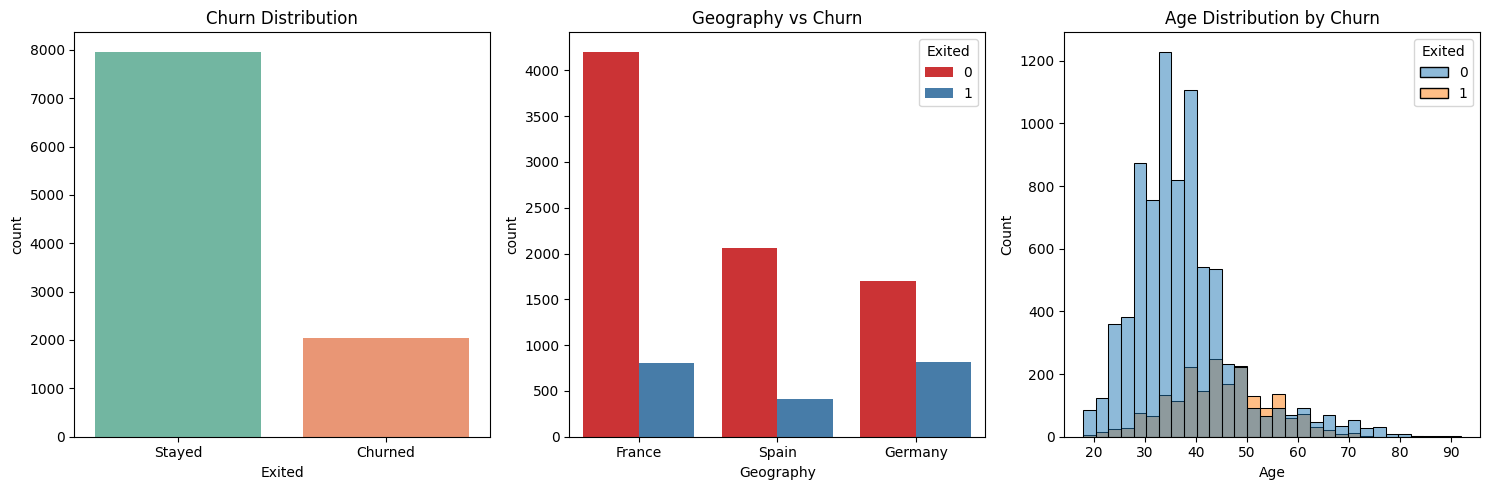

In [4]:
# Cell 4 - Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Churn distribution
sns.countplot(data=df, x='Exited', palette='Set2', ax=axes[0])
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['Stayed', 'Churned'])

# 2. Geography vs Churn
sns.countplot(data=df, x='Geography', hue='Exited', palette='Set1', ax=axes[1])
axes[1].set_title('Geography vs Churn')

# 3. Age distribution
sns.histplot(data=df, x='Age', hue='Exited', bins=30, ax=axes[2])
axes[2].set_title('Age Distribution by Churn')

plt.tight_layout()
plt.show()

In [5]:
# Cell 5 - Data preparation and model training

# Unnecessary columns drop karo
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Categorical columns encode karo
le = LabelEncoder()
df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])

# Features aur Target alag karo
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model train karo
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Model trained successfully!
Training size: (8000, 10)
Testing size: (2000, 10)


Model Accuracy: 79.90%


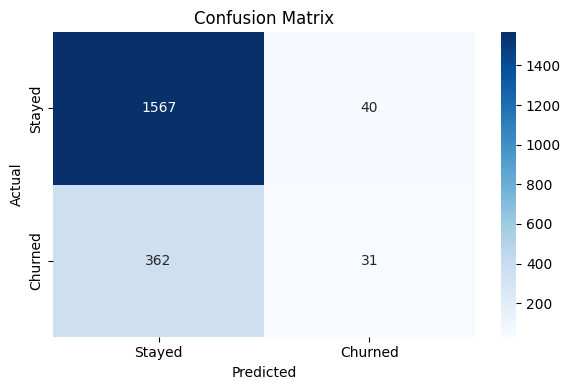

In [6]:
# Cell 6 - Model evaluation
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

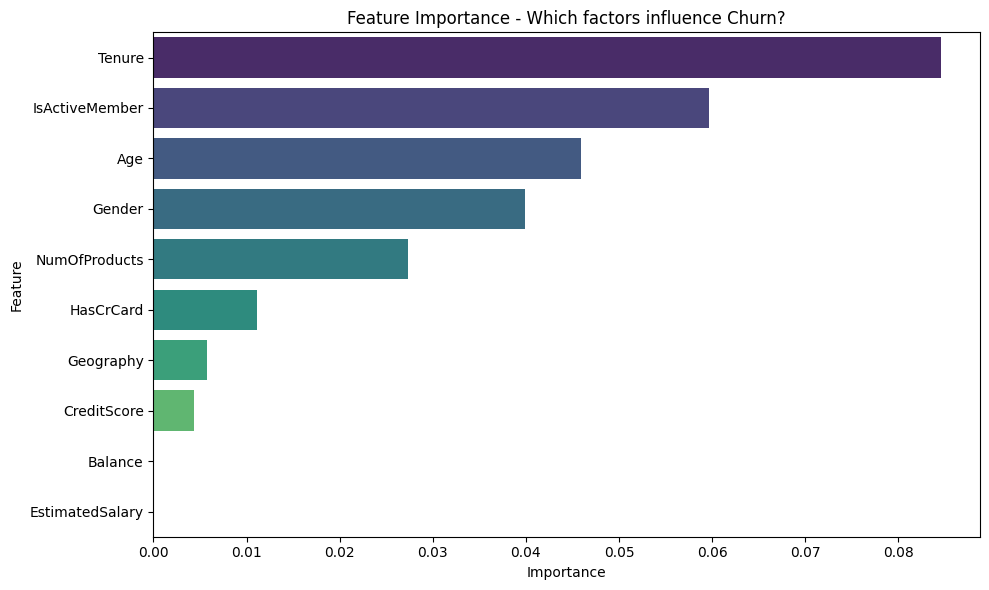

           Feature  Importance
4           Tenure    0.084545
8   IsActiveMember    0.059642
3              Age    0.045951
2           Gender    0.039866
6    NumOfProducts    0.027321
7        HasCrCard    0.011073
1        Geography    0.005793
0      CreditScore    0.004366
5          Balance    0.000003
9  EstimatedSalary    0.000001


In [7]:
# Cell 7 - Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_[0])
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Which factors influence Churn?')
plt.tight_layout()
plt.show()

print(importance)

In [8]:
# Cell 8 - Conclusion
print("""
TASK 3 - CONCLUSION
====================
Dataset: Churn Modelling Dataset (10,000 rows, 14 columns)

Data Preparation:
- No missing values found - dataset was already clean
- Removed irrelevant columns: RowNumber, CustomerId, Surname
- Encoded categorical features: Geography, Gender

Key Findings:
1. 79.6% customers stayed, 20.4% churned
2. Germany has the highest churn rate compared to France and Spain
3. Customers aged 40-50 are more likely to churn
4. Active members are less likely to leave the bank

Feature Importance:
- Tenure is the strongest predictor of churn
- IsActiveMember and Age are also highly influential
- Balance and EstimatedSalary have minimal impact

Model Performance:
- Algorithm: Logistic Regression
- Accuracy: 79.90%
- Model is strong at predicting customers who stay

Overall Insight:
Banks should focus on engaging older customers and 
customers with low tenure to reduce churn rate.
""")


TASK 3 - CONCLUSION
Dataset: Churn Modelling Dataset (10,000 rows, 14 columns)

Data Preparation:
- No missing values found - dataset was already clean
- Removed irrelevant columns: RowNumber, CustomerId, Surname
- Encoded categorical features: Geography, Gender

Key Findings:
1. 79.6% customers stayed, 20.4% churned
2. Germany has the highest churn rate compared to France and Spain
3. Customers aged 40-50 are more likely to churn
4. Active members are less likely to leave the bank

Feature Importance:
- Tenure is the strongest predictor of churn
- IsActiveMember and Age are also highly influential
- Balance and EstimatedSalary have minimal impact

Model Performance:
- Algorithm: Logistic Regression
- Accuracy: 79.90%
- Model is strong at predicting customers who stay

Overall Insight:
Banks should focus on engaging older customers and 
customers with low tenure to reduce churn rate.

